In [1]:
import pandas as pd
from pandas import DataFrame
from pathlib import Path
import datetime
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, accuracy_score, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import pyplot

from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
 



In [2]:
#import file
train = pd.read_csv('/Users/ericmerdian/Desktop/Desktop/A_Summer_Research/AllTeams/training.csv')
test = pd.read_csv('/Users/ericmerdian/Desktop/Desktop/A_Summer_Research/AllTeams/testing.csv')
                        
train.head()

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play
0,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,0,0,0,1,NaN,NaN,NaN,NaN,2395,5,"FOUL by NOTLEY,CHANDLER"
1,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,0,0,0,1,NaN,NaN,NaN,NaN,2380,20,"TURNOVER by JOHNSON,BRYSON"
2,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,2,0,-2,1,1.0,NaN,1.0,NaN,2377,23,"GOOD JUMPER by NOTLEY,CHANDLER"
3,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,2,0,-2,1,1.0,NaN,1.0,NaN,2377,23,"ASSIST by MOORE,AUSTIN"
4,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,2,0,-2,1,1.0,NaN,0.5,NaN,2365,35,"MISS JUMPER by BARNES,SKYLER"


In [3]:
test

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play
0,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"MISS 3PTR by GONDA,MATT"
1,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"REBOUND DEF by BRYAN,WILLIAM"
2,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"MISS 3PTR by SPRAGG,BAILEY"
3,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"REBOUND DEF by ALLISON,ZACHARY"
4,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2349,51,"MISS 3PTR by BAK,CALVIN"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"MISS 3PTR by STANLEY,SETH"
85408,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"REBOUND DEF by LEE,MATT"
85409,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.458,0.375,0.518,0.446,22,2378,"GOOD 3PTR by CARLETELLO,EMILY"
85410,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.452,0.364,0.514,0.439,16,2384,"MISS 3PTR by CALAMESE,MICHAEL"


In [4]:
test[test['GameID'] ==  '19_01_27_2_20']

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play
9161,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,1.000,NaN,2382,18,"GOOD LAYUP by STEWART,CHRISTIAN(in the paint)"
9162,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,1.000,NaN,2382,18,"ASSIST by SPENCE,BEN"
9163,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.500,NaN,2350,50,"MISS JUMPER by BATES,JACOB"
9164,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.500,NaN,2350,50,"REBOUND DEF by STEWART,CHRISTIAN"
9165,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.500,NaN,2340,60,"FOUL by STEWART,CHRISTIAN"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9634,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,71,17.0,2,0.467,0.269,0.481,0.300,36,2364,"MISS 3PTR by WILLIAMS,JALEN"
9635,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,71,17.0,2,0.467,0.269,0.481,0.300,36,2364,"REBOUND OFF by WILLIAMS,JALEN"
9636,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,73,19.0,2,0.467,0.269,0.485,0.300,30,2370,"GOOD LAYUP by WILLIAMS,JALEN(in the paint)"
9637,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,73,19.0,2,0.459,0.259,0.482,0.294,20,2380,"MISS 3PTR by ALLISON,ZACHARY"


In [5]:
## one-hot encode

#add win and loss column
df_add1 = pd.get_dummies(train.Outcome, prefix = 'Outcome',drop_first = True)
df_add2 = pd.get_dummies(test.Outcome, prefix = 'Outcome',drop_first = True)

train = pd.concat([train,df_add1], axis=1)
test = pd.concat([test,df_add2], axis=1)

In [6]:
train

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,0,0,0,1,NaN,NaN,NaN,NaN,2395,5,"FOUL by NOTLEY,CHANDLER",1
1,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,0,0,0,1,NaN,NaN,NaN,NaN,2380,20,"TURNOVER by JOHNSON,BRYSON",1
2,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,1.000,NaN,2377,23,"GOOD JUMPER by NOTLEY,CHANDLER",1
3,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,1.000,NaN,2377,23,"ASSIST by MOORE,AUSTIN",1
4,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,0.500,NaN,2365,35,"MISS JUMPER by BARNES,SKYLER",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95976,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,8,2392,"SUB OUT by EATON,JACK",0
95977,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,4,2396,"SUB IN by ROBERTS,ERIC",0
95978,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,4,2396,"SUB OUT by EATON,JACK",0
95979,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.507,0.326,1,2399,"MISS 3PTR by SMITH,LUKE",0


In [7]:
test

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"MISS 3PTR by GONDA,MATT",1
1,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"REBOUND DEF by BRYAN,WILLIAM",1
2,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"MISS 3PTR by SPRAGG,BAILEY",1
3,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"REBOUND DEF by ALLISON,ZACHARY",1
4,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2349,51,"MISS 3PTR by BAK,CALVIN",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"MISS 3PTR by STANLEY,SETH",1
85408,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"REBOUND DEF by LEE,MATT",1
85409,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.458,0.375,0.518,0.446,22,2378,"GOOD 3PTR by CARLETELLO,EMILY",1
85410,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.452,0.364,0.514,0.439,16,2384,"MISS 3PTR by CALAMESE,MICHAEL",1


In [8]:
train.groupby(['GameID', 'Outcome_Win']).ngroups

162

In [9]:
game_outcome = train.groupby(["GameID", "Outcome_Win"]).size().reset_index()

In [10]:
game_outcome

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
4,17_11_15_2_01,0,826
...,...,...,...
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398
160,18_02_25_4_28,0,446


In [11]:
game_outcome = pd.DataFrame(game_outcome)

In [12]:
game_outcome

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
4,17_11_15_2_01,0,826
...,...,...,...
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398
160,18_02_25_4_28,0,446


Based on the cell below, we can see that there are 30 more home games won than lost in this dataset.

In [13]:
game_outcome.groupby(['Outcome_Win']).size()

Outcome_Win
0    66
1    96
dtype: int64

In [14]:
game_outcome

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
4,17_11_15_2_01,0,826
...,...,...,...
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398
160,18_02_25_4_28,0,446


In [15]:
game_wins = game_outcome[game_outcome['Outcome_Win'] ==  1]
game_wins

,GameID,Outcome_Win,0
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
5,17_11_15_3_02,1,487
6,17_11_15_4_01,1,482
...,...,...,...
150,18_02_17_4_25,1,984
151,18_02_17_5_25,1,485
152,18_02_17_6_25,1,984
155,18_02_23_5_26,1,451


In [16]:
game_losses = game_outcome[game_outcome['Outcome_Win'] ==  0]
game_losses

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
4,17_11_15_2_01,0,826
8,17_11_15_7_02,0,457
12,17_11_18_2_03,0,571
16,17_11_19_4_03,0,509
...,...,...,...
156,18_02_23_6_26,0,930
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398


Because we want to have the same amount of wins as losses and there were 66 games lost by the home team in our training data, I then extracted 66 random game id's from the games won by the home team.

In [17]:
remove_n = 66
drop_indices = np.random.choice(game_wins.index, remove_n, replace=False)
df_subset = game_wins.drop(drop_indices)

In [18]:
len(df_subset)

30

In [19]:
remaining_games = df_subset['GameID']
remaining_games = pd.DataFrame(remaining_games)

In [20]:
len(remaining_games)

30

After all was said and done, we were left with 23 games won by the home team to filter out of our training set.

In [21]:
game_ids = remaining_games['GameID'].unique()
game_ids

array(['17_11_04_7_01', '17_11_17_4_02', '17_11_18_1_02', '17_11_28_4_06',
       '17_12_05_5_07', '17_12_16_5_09', '17_12_18_6_08', '17_12_19_1_09',
       '17_12_19_2_08', '17_12_21_2_09', '17_12_29_5_11', '17_12_29_7_10',
       '17_12_31_4_11', '18_01_05_1_13', '18_01_05_6_13', '18_01_07_5_14',
       '18_01_12_7_15', '18_01_21_2_18', '18_01_26_6_19', '18_02_02_1_21',
       '18_02_02_4_21', '18_02_02_5_21', '18_02_02_7_21', '18_02_09_3_23',
       '18_02_09_5_23', '18_02_09_6_23', '18_02_11_6_24', '18_02_17_2_25',
       '18_02_17_3_25', '18_02_23_5_26'], dtype=object)

In [22]:
len(game_ids)

30

In [23]:
b = np.asarray(game_ids)
b

array(['17_11_04_7_01', '17_11_17_4_02', '17_11_18_1_02', '17_11_28_4_06',
       '17_12_05_5_07', '17_12_16_5_09', '17_12_18_6_08', '17_12_19_1_09',
       '17_12_19_2_08', '17_12_21_2_09', '17_12_29_5_11', '17_12_29_7_10',
       '17_12_31_4_11', '18_01_05_1_13', '18_01_05_6_13', '18_01_07_5_14',
       '18_01_12_7_15', '18_01_21_2_18', '18_01_26_6_19', '18_02_02_1_21',
       '18_02_02_4_21', '18_02_02_5_21', '18_02_02_7_21', '18_02_09_3_23',
       '18_02_09_5_23', '18_02_09_6_23', '18_02_11_6_24', '18_02_17_2_25',
       '18_02_17_3_25', '18_02_23_5_26'], dtype=object)

We have now set our training set to contain 66 games won by the home team and 66 games lost by the home team.

In [24]:
train = train.loc[~train['GameID'].isin(b)]
train

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,0,0,0,1,NaN,NaN,NaN,NaN,2395,5,"FOUL by NOTLEY,CHANDLER",1
1,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,0,0,0,1,NaN,NaN,NaN,NaN,2380,20,"TURNOVER by JOHNSON,BRYSON",1
2,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,1.000,NaN,2377,23,"GOOD JUMPER by NOTLEY,CHANDLER",1
3,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,1.000,NaN,2377,23,"ASSIST by MOORE,AUSTIN",1
4,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,0.500,NaN,2365,35,"MISS JUMPER by BARNES,SKYLER",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95976,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,8,2392,"SUB OUT by EATON,JACK",0
95977,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,4,2396,"SUB IN by ROBERTS,ERIC",0
95978,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,4,2396,"SUB OUT by EATON,JACK",0
95979,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.507,0.326,1,2399,"MISS 3PTR by SMITH,LUKE",0


In [25]:
test

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"MISS 3PTR by GONDA,MATT",1
1,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"REBOUND DEF by BRYAN,WILLIAM",1
2,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"MISS 3PTR by SPRAGG,BAILEY",1
3,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"REBOUND DEF by ALLISON,ZACHARY",1
4,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2349,51,"MISS 3PTR by BAK,CALVIN",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"MISS 3PTR by STANLEY,SETH",1
85408,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"REBOUND DEF by LEE,MATT",1
85409,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.458,0.375,0.518,0.446,22,2378,"GOOD 3PTR by CARLETELLO,EMILY",1
85410,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.452,0.364,0.514,0.439,16,2384,"MISS 3PTR by CALAMESE,MICHAEL",1


In [26]:
test_copy = test

In [27]:
test_copy

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"MISS 3PTR by GONDA,MATT",1
1,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"REBOUND DEF by BRYAN,WILLIAM",1
2,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"MISS 3PTR by SPRAGG,BAILEY",1
3,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"REBOUND DEF by ALLISON,ZACHARY",1
4,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2349,51,"MISS 3PTR by BAK,CALVIN",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"MISS 3PTR by STANLEY,SETH",1
85408,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"REBOUND DEF by LEE,MATT",1
85409,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.458,0.375,0.518,0.446,22,2378,"GOOD 3PTR by CARLETELLO,EMILY",1
85410,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.452,0.364,0.514,0.439,16,2384,"MISS 3PTR by CALAMESE,MICHAEL",1


In [28]:
#drop columns that are not used
unused_columns = ['GameID','VisitorName','HomeName', 'Outcome', 'Away Team Score', 'Time Remaining Secs', 'Play']

train = train.drop(unused_columns, axis = 1)
test = test.drop(unused_columns, axis = 1)

train.head()

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
0,0.5,0.5,0,0,1,NaN,NaN,NaN,NaN,5,1
1,0.5,0.5,0,0,1,NaN,NaN,NaN,NaN,20,1
2,0.5,0.5,0,-2,1,1.0,NaN,1.0,NaN,23,1
3,0.5,0.5,0,-2,1,1.0,NaN,1.0,NaN,23,1
4,0.5,0.5,0,-2,1,1.0,NaN,0.5,NaN,35,1


In [29]:
train.describe()

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
count,76643.000000,76643.000000,76643.000000,76643.000000,76643.000000,76419.000000,74322.000000,76595.000000,75886.000000,76643.000000,76643.000000
mean,0.442028,0.451321,42.815495,0.039456,1.516890,0.516152,0.366338,0.499666,0.354156,1252.919993,0.493757
std,0.158437,0.161521,27.168243,11.770552,0.501256,0.134329,0.203107,0.095061,0.133707,693.999231,0.499964
min,0.000000,0.000000,0.000000,-56.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.304000,0.333000,20.000000,-7.000000,1.000000,0.438000,0.250000,0.452000,0.286000,646.000000,0.000000
50%,0.500000,0.500000,41.000000,-1.000000,2.000000,0.506000,0.364000,0.500000,0.355000,1256.000000,0.000000
75%,0.500000,0.500000,63.000000,6.000000,2.000000,0.600000,0.478000,0.552000,0.422000,1863.000000,1.000000
max,1.000000,1.000000,141.000000,63.000000,3.000000,1.000000,1.000000,1.000000,1.000000,2700.000000,1.000000


Now that the number of games has been balanced out, it was important to check that the number of rows also balanced our (roughly). Here we can see there are about 500 additional rows for the home team won games, but not a huge deal.

In [30]:
train.groupby(['Outcome_Win']).size()

Outcome_Win
0    38800
1    37843
dtype: int64

In [31]:
test.head()

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
0,0.5,0.5,0,0.0,1,NaN,NaN,0.0,0.0,28,1
1,0.5,0.5,0,0.0,1,NaN,NaN,0.0,0.0,28,1
2,0.5,0.5,0,0.0,1,0.0,0.0,0.0,0.0,39,1
3,0.5,0.5,0,0.0,1,0.0,0.0,0.0,0.0,39,1
4,0.5,0.5,0,0.0,1,0.0,0.0,0.0,0.0,51,1


In [32]:
test = test[test['Home Team Score'] != '(+5)']

In [33]:
test_copy = test_copy[test_copy['Home Team Score'] != '(+5)']

In [34]:
test_copy = test_copy[test_copy['Home Team Score'] != '(+1)']

In [35]:
home_team = test_copy['HomeName']

In [36]:
visit_team = test_copy['VisitorName']

In [37]:
play_description = test_copy['Play']

In [38]:
play_description

0               MISS 3PTR by GONDA,MATT
1          REBOUND DEF by BRYAN,WILLIAM
2            MISS 3PTR by SPRAGG,BAILEY
3        REBOUND DEF by ALLISON,ZACHARY
4               MISS 3PTR by BAK,CALVIN
                      ...              
85407         MISS 3PTR by STANLEY,SETH
85408           REBOUND DEF by LEE,MATT
85409     GOOD 3PTR by CARLETELLO,EMILY
85410     MISS 3PTR by CALAMESE,MICHAEL
85411               REBOUND OFF by TEAM
Name: Play, Length: 85406, dtype: object

In [39]:
test = test[test['Home Team Score'] != '(+1)']

In [40]:
test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
0,0.5,0.50,0,0.0,1,NaN,NaN,0.000,0.000,28,1
1,0.5,0.50,0,0.0,1,NaN,NaN,0.000,0.000,28,1
2,0.5,0.50,0,0.0,1,0.000,0.000,0.000,0.000,39,1
3,0.5,0.50,0,0.0,1,0.000,0.000,0.000,0.000,39,1
4,0.5,0.50,0,0.0,1,0.000,0.000,0.000,0.000,51,1
...,...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458,0.375,0.514,0.436,2349,1
85408,0.4,0.76,79,15.0,2,0.458,0.375,0.514,0.436,2349,1
85409,0.4,0.76,82,18.0,2,0.458,0.375,0.518,0.446,2378,1
85410,0.4,0.76,82,18.0,2,0.452,0.364,0.514,0.439,2384,1


In [41]:
train = train.fillna(train.mean())

In [42]:
test = test.fillna(train.mean())

test = test.fillna(train.mean())

test = test.dropna()

In [43]:
y_train = train['Outcome_Win']
y_test = test['Outcome_Win']

In [44]:
X_train = train.drop(['Outcome_Win'], axis = 1)
X_test = test.drop(['Outcome_Win'], axis = 1)

X_train

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
0,0.5,0.500,0,0,1,0.516152,0.366338,0.499666,0.354156,5
1,0.5,0.500,0,0,1,0.516152,0.366338,0.499666,0.354156,20
2,0.5,0.500,0,-2,1,1.000000,0.366338,1.000000,0.354156,23
3,0.5,0.500,0,-2,1,1.000000,0.366338,1.000000,0.354156,23
4,0.5,0.500,0,-2,1,1.000000,0.366338,0.500000,0.354156,35
...,...,...,...,...,...,...,...,...,...,...
95976,0.2,0.583,67,-2,2,0.487000,0.300000,0.510000,0.333000,2392
95977,0.2,0.583,67,-2,2,0.487000,0.300000,0.510000,0.333000,2396
95978,0.2,0.583,67,-2,2,0.487000,0.300000,0.510000,0.333000,2396
95979,0.2,0.583,67,-2,2,0.487000,0.300000,0.507000,0.326000,2399


In [45]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
0,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
1,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
2,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
3,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
4,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,51
...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446,2378
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439,2384


In [46]:
test_game_ids = test_copy['GameID']

train = train.drop('GameID', axis = 1)
test = test.drop('GameID', axis = 1)

In [47]:
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

X_train_scaled= std_scaler.fit_transform(X_train)
X_test_scaled= std_scaler.transform(X_test)

X_train_scaled

array([[ 3.65904107e-01,  3.01382492e-01, -1.57594936e+00, ...,
         1.12738778e-13, -4.29755235e-14, -1.79816933e+00],
       [ 3.65904107e-01,  3.01382492e-01, -1.57594936e+00, ...,
         1.12738778e-13, -4.29755235e-14, -1.77655533e+00],
       [ 3.65904107e-01,  3.01382492e-01, -1.57594936e+00, ...,
         5.26496820e+00, -4.29755235e-14, -1.77223253e+00],
       ...,
       [-1.52760850e+00,  8.15252341e-01,  8.90181336e-01, ...,
         1.08743220e-01, -1.59014976e-01,  1.64710192e+00],
       [-1.52760850e+00,  8.15252341e-01,  8.90181336e-01, ...,
         7.71744957e-02, -2.11629029e-01,  1.65142472e+00],
       [-1.52760850e+00,  8.15252341e-01,  8.90181336e-01, ...,
         7.71744957e-02, -2.11629029e-01,  1.65142472e+00]])

In [48]:
X_test_scaled

array([[ 0.36590411,  0.30138249, -1.57594936, ..., -5.25793992,
        -2.66194064, -1.76502787],
       [ 0.36590411,  0.30138249, -1.57594936, ..., -5.25793992,
        -2.66194064, -1.76502787],
       [ 0.36590411,  0.30138249, -1.57594936, ..., -5.25793992,
        -2.66194064, -1.7491776 ],
       ...,
       [-0.26526676,  1.91109527,  1.44230015, ...,  0.19292649,
         0.69032616,  1.62116512],
       [-0.26526676,  1.91109527,  1.44230015, ...,  0.15083485,
         0.63771211,  1.62981072],
       [-0.26526676,  1.91109527,  1.44230015, ...,  0.15083485,
         0.63771211,  1.62981072]])

In [49]:
logreg = LogisticRegression()

# fit the model with data
logreg.fit(X_train,y_train)

y_pred=logreg.predict(X_test)

# try:
#     y_pred=logreg.predict(X_test)
# except:
#     print("error")

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

Compared to the previous model that simply spit out that the home team always won, this is a significant improvement, albeit one that still needs work.

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1 Score:",metrics.f1_score(y_test, y_pred))
print("AUC Score:",metrics.roc_auc_score(y_test, y_pred))
# print("R^2 value: ", logreg.score(X_test.values.reshape(-1, 1), y_test))

In [50]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
0,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
1,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
2,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
3,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
4,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,51
...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446,2378
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439,2384


In [51]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], dtype=uint8)

In [52]:
y_test

0        1
1        1
2        1
3        1
4        1
        ..
85407    1
85408    1
85409    1
85410    1
85411    1
Name: Outcome_Win, Length: 85406, dtype: uint8

In [53]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
0,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
1,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
2,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
3,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
4,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,51
...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446,2378
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439,2384


In [54]:
len(y_pred)

85406

In [55]:
data_outcome = pd.DataFrame((y_test == 1) & (y_pred == 0))
data_outcome

,Outcome_Win
0,False
1,False
2,False
3,False
4,False
...,...
85407,False
85408,False
85409,False
85410,False


In [56]:
data_outcome.groupby(['Outcome_Win']).size()

Outcome_Win
False    75134
True     10272
dtype: int64

I found the following code online and it has run beofre but doesn't currently for some reason.

In [57]:
clf = LogisticRegression(random_state = 42, max_iter=1000)
clf.fit(X_train,y_train)
classes = logreg.predict(X_test)
probs = logreg.predict_proba(X_test)
print(np.bincount(classes))

[32540 52866]


In [58]:
importance = logreg.coef_
print(importance)
# summarize feature importance
# for i,v in enumerate(importance):
# 	print('Feature: %0d, Score: %.5f' % (i,v))

[[-2.04353847e+00  4.01758630e+00  6.49729524e-04  2.29682175e-01
  -2.36764440e-01  1.69867399e+00  1.13512593e-01 -1.18092743e+00
  -9.91025678e-01 -4.42384409e-05]]


In [59]:
importance = importance[0]

In [60]:
importance

array([-2.04353847e+00,  4.01758630e+00,  6.49729524e-04,  2.29682175e-01,
       -2.36764440e-01,  1.69867399e+00,  1.13512593e-01, -1.18092743e+00,
       -9.91025678e-01, -4.42384409e-05])

Insert a bar chart of these values * 100

In [61]:
cols = []
for i in X_train.columns:
    cols.append(i)

In [62]:
cols

['VisitorWinPercent',
 'HomeWinPercent',
 'Home Team Score',
 'Point Differential',
 'Period',
 'Home Shooting PCT',
 'Home 3PTRs PCT',
 'Away Shooting PCT',
 'Away 3PTRs PCT',
 'Seconds Elapsed']

In [88]:
cols = ['Home Win PCT', 'Home Shooting PCT', 'Away Shooting PCT', 'Visitor Win PCT', 'Away 3PTRs PCT', 
        'Point Differential', 'Period', 'Home 3PTRs PCT', 'Home Team Score', 'Seconds Elapsed']

In [89]:
cols.reverse()

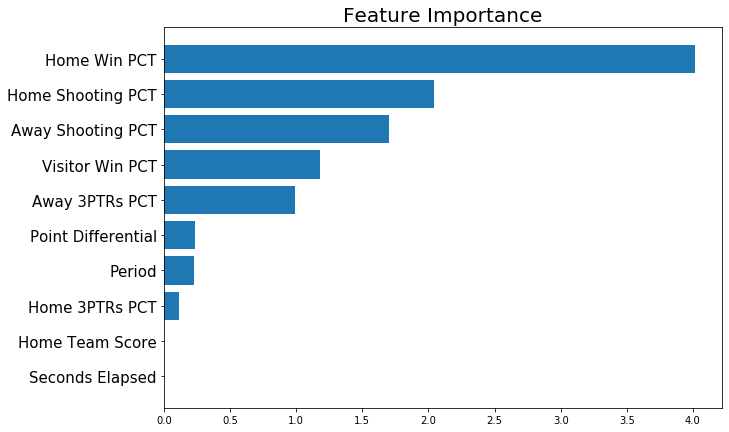

In [90]:
plt.figure(figsize=(10,7))
plt.barh(cols, width = sorted(np.absolute(importance), reverse=False))
plt.title("Feature Importance", fontsize=20)

plt.tick_params(axis='y', which='major', labelsize=15)


In [66]:
win_prob = clf.predict_proba(X_test)
win_prob

array([[0.07394075, 0.92605925],
       [0.07394075, 0.92605925],
       [0.47832749, 0.52167251],
       ...,
       [0.00535775, 0.99464225],
       [0.00539049, 0.99460951],
       [0.00539049, 0.99460951]])

In [67]:
win_prob = pd.DataFrame(win_prob)

In [68]:
win_prob = win_prob[1]

In [69]:
win_prob

0        0.926059
1        0.926059
2        0.521673
3        0.521673
4        0.522184
           ...   
85401    0.989026
85402    0.989026
85403    0.994642
85404    0.994610
85405    0.994610
Name: 1, Length: 85406, dtype: float64

In [70]:
win_prob = clf.predict_proba(X_test)[:,1]

In [71]:
len(X_test)

85406

In [72]:
sub = X_test

In [73]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
0,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
1,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28
2,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
3,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39
4,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,51
...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446,2378
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439,2384


In [74]:
X_test.loc[X_test['Period'] == 4]

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
10146,0.526,0.550,78,0.0,4,0.500,0.407,0.500,0.396,2700
10147,0.526,0.550,78,0.0,4,0.500,0.407,0.500,0.396,2700
10148,0.526,0.550,78,0.0,4,0.500,0.407,0.500,0.396,2700
10149,0.526,0.550,78,0.0,4,0.500,0.407,0.500,0.396,2700
10150,0.526,0.550,80,2.0,4,0.500,0.407,0.503,0.396,2706
...,...,...,...,...,...,...,...,...,...,...
29428,0.571,0.857,80,-1.0,4,0.549,0.390,0.549,0.390,2978
29429,0.571,0.857,80,-1.0,4,0.549,0.390,0.549,0.390,2984
29430,0.571,0.857,82,1.0,4,0.552,0.390,0.552,0.390,2998
29431,0.571,0.857,82,1.0,4,0.548,0.381,0.548,0.381,3000


In [75]:
sub = pd.DataFrame(sub)

In [76]:
win_prob

array([0.92605925, 0.92605925, 0.52167251, ..., 0.99464225, 0.99460951,
       0.99460951])

In [77]:
sub['WinProb'] = win_prob

In [78]:
sub['GameID'] = test_game_ids

In [79]:
sub['Outcome'] = y_test

In [80]:
sub['Play'] = play_description

In [81]:
sub['Home Team'] = home_team

In [82]:
sub['Away Team'] = visit_team

In [83]:
sub

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,GameID,Outcome,Play,Home Team,Away Team
0,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28,0.926059,18_11_10_2_01,1,"MISS 3PTR by GONDA,MATT",Birmingham-Southern,Covenant College
1,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28,0.926059,18_11_10_2_01,1,"REBOUND DEF by BRYAN,WILLIAM",Birmingham-Southern,Covenant College
2,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39,0.521673,18_11_10_2_01,1,"MISS 3PTR by SPRAGG,BAILEY",Birmingham-Southern,Covenant College
3,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39,0.521673,18_11_10_2_01,1,"REBOUND DEF by ALLISON,ZACHARY",Birmingham-Southern,Covenant College
4,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,51,0.522184,18_11_10_2_01,1,"MISS 3PTR by BAK,CALVIN",Birmingham-Southern,Covenant College
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349,0.989026,19_02_22_4_27,1,"MISS 3PTR by STANLEY,SETH",Sewanee,Hendrix
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349,0.989026,19_02_22_4_27,1,"REBOUND DEF by LEE,MATT",Sewanee,Hendrix
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446,2378,0.994642,19_02_22_4_27,1,"GOOD 3PTR by CARLETELLO,EMILY",Sewanee,Hendrix
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439,2384,0.994610,19_02_22_4_27,1,"MISS 3PTR by CALAMESE,MICHAEL",Sewanee,Hendrix


In [84]:
sub[sub['GameID'] == '19_02_22_4_27']

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,GameID,Outcome,Play,Home Team,Away Team
84979,0.4,0.76,2,2.0,1,0.516152,0.366338,1.000,0.354156,16,0.459874,19_02_22_4_27,1,"GOOD LAYUP by LEE,MATT(in the paint)",Sewanee,Hendrix
84980,0.4,0.76,2,2.0,1,0.516152,0.366338,1.000,0.354156,16,0.459874,19_02_22_4_27,1,"ASSIST by KIM,SUE",Sewanee,Hendrix
84981,0.4,0.76,2,2.0,1,0.516152,0.366338,1.000,0.354156,35,0.460681,19_02_22_4_27,1,"FOUL by SMITH,PRESTON",Sewanee,Hendrix
84982,0.4,0.76,2,2.0,1,0.516152,0.366338,1.000,0.354156,35,0.460681,19_02_22_4_27,1,"TURNOVER by SMITH,PRESTON",Sewanee,Hendrix
84983,0.4,0.76,2,2.0,1,0.516152,0.366338,1.000,0.354156,62,0.461828,19_02_22_4_27,1,"FOUL by BUESCHER,HUNTER",Sewanee,Hendrix
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436000,2349,0.989026,19_02_22_4_27,1,"MISS 3PTR by STANLEY,SETH",Sewanee,Hendrix
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436000,2349,0.989026,19_02_22_4_27,1,"REBOUND DEF by LEE,MATT",Sewanee,Hendrix
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446000,2378,0.994642,19_02_22_4_27,1,"GOOD 3PTR by CARLETELLO,EMILY",Sewanee,Hendrix
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439000,2384,0.994610,19_02_22_4_27,1,"MISS 3PTR by CALAMESE,MICHAEL",Sewanee,Hendrix


In [85]:
sub.describe()

,VisitorWinPercent,HomeWinPercent,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,Outcome
count,85406.000000,85406.000000,85406.000000,85406.000000,85406.000000,85406.000000,85406.000000,85406.000000,85406.000000,8.540600e+04,85406.000000
mean,0.562328,0.560194,1.858734,1.538147,0.463641,0.322565,0.472259,0.326032,1270.975693,5.866543e-01,0.659275
std,0.196615,0.195671,11.546085,0.533621,0.121266,0.183921,0.090697,0.133618,705.511063,3.418250e-01,0.473956
min,0.000000,0.000000,-50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.953207e-07,0.000000
25%,0.500000,0.500000,-4.000000,1.000000,0.404000,0.222000,0.435000,0.256000,661.250000,2.748863e-01,0.000000
50%,0.500000,0.500000,2.000000,2.000000,0.467000,0.333000,0.479000,0.333000,1256.500000,6.665181e-01,1.000000
75%,0.700000,0.722000,8.000000,2.000000,0.531000,0.409000,0.522000,0.400000,1879.000000,9.098027e-01,1.000000
max,1.000000,1.000000,48.000000,4.000000,1.000000,1.000000,1.000000,1.000000,3000.000000,9.999892e-01,1.000000


In [86]:
sub

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,GameID,Outcome,Play,Home Team,Away Team
0,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28,0.926059,18_11_10_2_01,1,"MISS 3PTR by GONDA,MATT",Birmingham-Southern,Covenant College
1,0.5,0.50,0,0.0,1,0.516152,0.366338,0.000,0.000,28,0.926059,18_11_10_2_01,1,"REBOUND DEF by BRYAN,WILLIAM",Birmingham-Southern,Covenant College
2,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39,0.521673,18_11_10_2_01,1,"MISS 3PTR by SPRAGG,BAILEY",Birmingham-Southern,Covenant College
3,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,39,0.521673,18_11_10_2_01,1,"REBOUND DEF by ALLISON,ZACHARY",Birmingham-Southern,Covenant College
4,0.5,0.50,0,0.0,1,0.000000,0.000000,0.000,0.000,51,0.522184,18_11_10_2_01,1,"MISS 3PTR by BAK,CALVIN",Birmingham-Southern,Covenant College
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349,0.989026,19_02_22_4_27,1,"MISS 3PTR by STANLEY,SETH",Sewanee,Hendrix
85408,0.4,0.76,79,15.0,2,0.458000,0.375000,0.514,0.436,2349,0.989026,19_02_22_4_27,1,"REBOUND DEF by LEE,MATT",Sewanee,Hendrix
85409,0.4,0.76,82,18.0,2,0.458000,0.375000,0.518,0.446,2378,0.994642,19_02_22_4_27,1,"GOOD 3PTR by CARLETELLO,EMILY",Sewanee,Hendrix
85410,0.4,0.76,82,18.0,2,0.452000,0.364000,0.514,0.439,2384,0.994610,19_02_22_4_27,1,"MISS 3PTR by CALAMESE,MICHAEL",Sewanee,Hendrix


In [87]:
sub.to_csv('submission.csv',index=False)  

Now that we have the output file, we can now explore the data in the Visualizations